# Gradient Descent Based Optimization II
# Gradient Descent

This article is part of a series, listed below:
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Gradient%20Descent%20I%20-%20Derivatives%20and%20Partial%20Derivatives.ipynb">Gradient Descent I - Derivatives and Partial Derivatives</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Gradient%20Descent%20II%20-%20Gradient%20Descent.ipynb">Gradient Descent II - Gradient Descent</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Gradient%20Descent%20III%20-%20Extensions%20of%20GD">Gradient Descent III - Extensions of GD</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Gradient%20Descent%20IV%20-%20More%20Extensions%20of%20GD.ipynb">Gradient Descent IV - More Extensions of GD</a>

## Function Optimization

<p>Function optimization refers to finding the set of inputs that minimize or maximize a function. The function we wish to minimize or maximize is called the objective function, which when minimizing, could also be called a cost function or loss function.</p>

<p><a href="https://en.wikipedia.org/wiki/Stochastic_optimization">Stochastic algorithms</a> make use of randomness, and can involve much sampling of the objective function (though also deal with deceptive local minima). First-order optimization algorithms use the first-order derivative to choose which direction to move in the search space.</p>

## Derivatives and Partial Derivatives

<p><a href="https://github.com/pw598/Articles/blob/main/Gradient%20Descent%20I%20-%20Derivatives%20and%20Partial%20Derivatives.ipynb">Recall</a> that the derivative of a function $f(x)$, denoted as $f'(x)$ or $\frac{df}{dx}$, gives the slope of $f(x)$ at point $x$. It specifies how to scale a small change in the input to obtain the corresponding change in the output. We can therefore reduce $f(x)$ by moving along $x$ in small steps in the opposite sign of the derivative.</p>

<p>For functions with multiple inputs, the concept of partial derivatives $\frac{\partial f}{\partial x}$, $\frac{\partial x}{\partial y}, \ldots$, measure how $f(x,y,\ldots)$ changes with respect to individual variables, and the vector of partial derivatives for all variables is referred to as the gradient $\nabla f(x,y,\ldots)$.</p>

## Gradient Descent

<p>Gradient descent is a first-order optimization algorithm, meaning it makes use of the gradient of a multivariate function to move towards its minima. The sign of the gradient at a point tells you whether the function is increasing or decreasing at that point. Gradient descent begins at a starting point $x$, such as a randomly selected point in the input space, and movements are made by first calculating learning rate $\eta$ (a.k.a. step size), and then multiplying it against the gradient.</p>

<h4>$x_{new} = x - \eta \nabla f(x)$</h4>

<p>Gradient descent is the basis for the optimization algorithm used to train deep learning networks, referred to as stochastic gradient descent (SGD). In SGD, the gradient is approximated from samples (batches) of data. Normally, gradient descent is run until the value of $x$ does not change, the change is below a certain threshold, or a maximum number of iterations has been reached.</p>

## Example

<p>Consider the function $x^3 + 2y^2$, and a learning rate of $0.1$. The gradient vector is given by:</p>

<p>$\nabla f(x,y) = 3xi + 4yj$</p>

<p>The general equation for each step of gradient descent is as follows:</p>

<p>$x[t] = x[t-1] - \eta \nabla f(x[t-1])$</p>

<p>The value of $x[0]$ is often a random initialization. For the purpose of this example, we will arbitrarily say that $x[0] = (4,5)$, and follow the gradient descent process for two iterations.</p>

<p>At $t=0$:</p>
    <ul>
        <li>$x[0] = (4,5)$</li>
    </ul>

<p>At $t=1$:</p>
    <ul>
        <li>$x[1] = x[0] - \eta \nabla f(x[0])$</li>
        <li>$x[1] = (4,5) - 0.1 \times ( (3 \times 4), (4 \times 5) )$</li>
        <li>$x[1] = (2.8, 3.0)$</li>
    </ul>

<p>At $t=2$:</p>
    <ul>
        <li>$x[2] = x[1] - \eta \nabla f(x[1])$</li>
        <li>$x[2] = (2.8, 3.0) - 0.1 \times ( (3 \times 2.8), (4 \times 3.0) )$</li>
        <li>$x[2] = (1.96, 1.8)$</li>
    </ul>

## Code - Gradient Descent in One Dimension

In [1]:
# Adapted from Optimization for Machine Learning, Jason Brownlee
# https://machinelearningmastery.com/optimization-for-machine-learning/

First, we'll import necessary libraries.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from numpy import meshgrid

Then, create an objective function and define its derivative function.

In [3]:
def objective(x):
    return x**2 + 4

def d_objective(x):
    return 2*x

Then, define a function to perform the steps discussed above. Starting at a random point, we find the gradient and take a step in the negative direction, modulated by the size of the learning rate, and then repeat.

In [4]:
def grad_descent(objective, derivative, n_iter, lr):
    
    solutions = []
    scores = []
    solution = np.random.rand()*-1 + np.random.rand()

    for i in range(n_iter):
        gradient = d_objective(solution)
        solution = solution - lr * gradient
        solution_eval = objective(solution)
        solutions.append(solution)
        scores.append(solution_eval)
        print('>%d f(%.5f) = %.5f' % (i, solution, solution_eval))
    return solutions, scores

We then run the function, printing out the scores and solutions at each step.

In [5]:
np.random.seed(7)
n_iter = 20
lr = 0.1

solutions, scores = grad_descent(objective, d_objective, n_iter, lr)

>0 f(0.56289) = 4.31684
>1 f(0.45031) = 4.20278
>2 f(0.36025) = 4.12978
>3 f(0.28820) = 4.08306
>4 f(0.23056) = 4.05316
>5 f(0.18445) = 4.03402
>6 f(0.14756) = 4.02177
>7 f(0.11805) = 4.01393
>8 f(0.09444) = 4.00892
>9 f(0.07555) = 4.00571
>10 f(0.06044) = 4.00365
>11 f(0.04835) = 4.00234
>12 f(0.03868) = 4.00150
>13 f(0.03095) = 4.00096
>14 f(0.02476) = 4.00061
>15 f(0.01980) = 4.00039
>16 f(0.01584) = 4.00025
>17 f(0.01268) = 4.00016
>18 f(0.01014) = 4.00010
>19 f(0.00811) = 4.00007


The journey can be plotted as such:

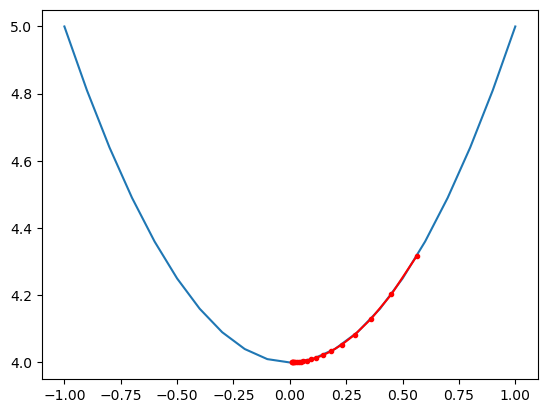

In [6]:
x = np.arange(-1, 1.1, 0.1)
results = objective(x)

plt.plot(x, results)
plt.plot(solutions, scores, '.-', color='red')
plt.show()

## Code - Gradient Descent in Two Dimensions

We'll define a two-dimensional objective function and derivative function.

In [7]:
def objective_2d(x, y): 
    return 2*x**2.0 + 4*y**2.0

def d_objective_2d(x, y):
    return np.asarray([2*x, 2*y])

Then define a function similar to above, but which takes into account the multiple dimensions of the solution.

In [8]:
def grad_descent_2d(objective, derivative, n_iter, lr):
    
    solutions = []
    solution = np.random.rand(2)*-1 + np.random.rand(2)

    for i in range(n_iter):
        gradient = d_objective_2d(solution[0], solution[1])
        solution = solution - lr * gradient
        solution_eval = objective(solution[0], solution[1])
        solutions.append(solution)
        print('>%d f(%s) = %.5f' % (i, solution, solution_eval))
    return solutions

We'll keep the same hyperparameters as above, and apply them to the function we just defined.

In [9]:
# np.random.seed(7)
# n_iter = 20
# lr = 0.1

solutions = grad_descent_2d(objective_2d, d_objective_2d, n_iter, lr)

>0 f([ 0.43166422 -0.14797545]) = 0.46025
>1 f([ 0.34533138 -0.11838036]) = 0.29456
>2 f([ 0.2762651  -0.09470429]) = 0.18852
>3 f([ 0.22101208 -0.07576343]) = 0.12065
>4 f([ 0.17680967 -0.06061074]) = 0.07722
>5 f([ 0.14144773 -0.04848859]) = 0.04942
>6 f([ 0.11315819 -0.03879088]) = 0.03163
>7 f([ 0.09052655 -0.0310327 ]) = 0.02024
>8 f([ 0.07242124 -0.02482616]) = 0.01296
>9 f([ 0.05793699 -0.01986093]) = 0.00829
>10 f([ 0.04634959 -0.01588874]) = 0.00531
>11 f([ 0.03707967 -0.01271099]) = 0.00340
>12 f([ 0.02966374 -0.0101688 ]) = 0.00217
>13 f([ 0.02373099 -0.00813504]) = 0.00139
>14 f([ 0.01898479 -0.00650803]) = 0.00089
>15 f([ 0.01518783 -0.00520642]) = 0.00057
>16 f([ 0.01215027 -0.00416514]) = 0.00036
>17 f([ 0.00972021 -0.00333211]) = 0.00023
>18 f([ 0.00777617 -0.00266569]) = 0.00015
>19 f([ 0.00622094 -0.00213255]) = 0.00010


Then, plot the results.

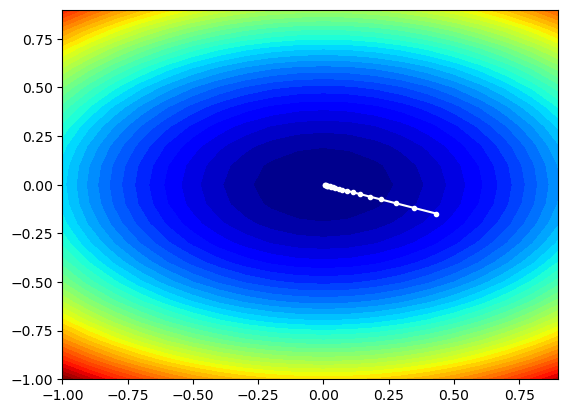

In [10]:
xaxis = np.arange(-1, 1, 0.1)
yaxis = np.arange(-1, 1, 0.1)
x, y = meshgrid(xaxis, yaxis)

results = objective_2d(x, y)
plt.contourf(x, y, results, levels=50, cmap='jet')
solutions = np.asarray(solutions)
plt.plot(solutions[:, 0], solutions[:, 1], '.-', color='w')
plt.show()

The next article, about extensions of gradient descent, can be found <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Gradient%20Descent%20III%20-%20Extensions%20of%20GD">here</a>.

# References

- Brownlee, J. (2021). Optimization for Machine Learning (A. Tam, Ed.) (1st ed.). MachineLearningMastery. https://machinelearningmastery.com/optimization-for-machine-learning/

- Cristina, S., Saeed, M., & Tam, A. (2022). Calculus for Machine Learning (1st ed.). MachineLearningMastery. https://machinelearningmastery.com/calculus-for-machine-learning/

- Cohen, M. X. (2024). Master calculus 1 using Python: Derivatives and applications [Online Video]. Udemy. https://www.udemy.com/course/pycalc1_x

- Cohen, M. X. (2024). A deep understanding of deep learning [Online Video]. Udemy. https://www.udemy.com/course/deeplearning_x

- Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press. https://www.deeplearningbook.org/